In [1]:
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import einops
import numpy as np
import torch
import os
import pickle
import random

from model.layers.encoder import *
from model.layers.decoder import *
from model.layers.processor import *
from model.layers.graph_net_block import *
from model.data.dataloader_graphnet import *
from model.data.load_data import *
from model.utils import parse_years, baseline_mol_updated, write_to_file

from model.forecast import GraphSatelliteForecaster, GraphSatelliteForecasterClassifier, GraphSatelliteForecasterConvClassifier
from model.loss_functions import *

import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random
from datetime import date


/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds_loaded = xr.open_dataset("satellite_outputs.nc")

In [3]:
outputs_sum = ds_loaded.outputs.sum(dim="direction")  # (time,)
outputs_sum = outputs_sum * 1e9 # Need to make it similar values to the box plot values
outputs_no2018 = outputs_sum.sel(time=outputs_sum.time.dt.year != 2018)




## Yearly values

In [1]:
yearly_mean = outputs_sum.groupby("year").mean()
yearly_mean.plot(marker="o")

NameError: name 'outputs_sum' is not defined

## Single year monthly values

In [ ]:
#monthly_mean_2014 = outputs_sum.sel(year=2014).groupby("month").mean()
#monthly_mean_2014.plot(marker="o", title="Monthly Mean of Outputs Sum (2019)")

KeyError: "no index found for coordinate 'year'"

## Continous Monthly values

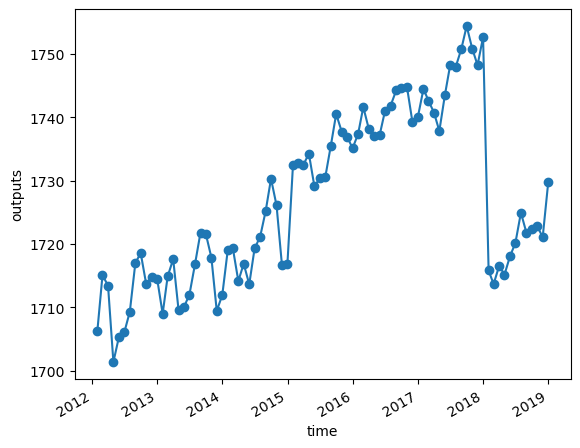

In [31]:
monthly_series = outputs_sum.resample(time="1M").mean()
monthly_series.plot(marker="o")

# Biased adjusted

In [34]:
baseline_vals = ds_loaded.baseline[:, 3]  # 1D array of baseline values (time,)
outputs_minus_baseline = outputs_sum - baseline_vals

In [27]:
baseline_vals.values

array([1774.61665962, 1774.61665962, 1774.61665962, ..., 1813.99857144,
       1813.99857144, 1813.99857144])

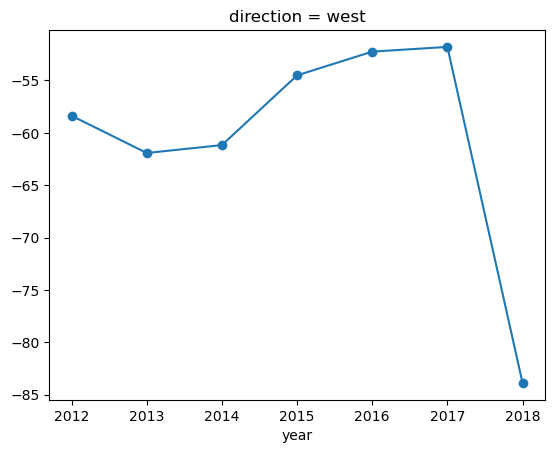

In [35]:
yearly_mean = outputs_minus_baseline.groupby("year").mean()
yearly_mean.plot(marker="o")

In [36]:
monthly_mean_2014 = (outputs_minus_baseline
                     .groupby("year")
                     .get_group(2014)
                     .groupby("month")
                     .mean())
monthly_mean_2014.plot(marker="o")


AttributeError: 'DataArrayGroupBy' object has no attribute 'get_group'

# Continous monthly

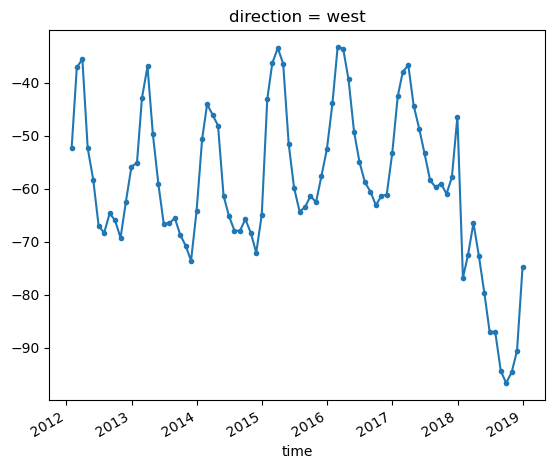

In [37]:
monthly_series = outputs_minus_baseline.resample(time="1M").mean()
monthly_series.plot(marker=".")

# Histograms

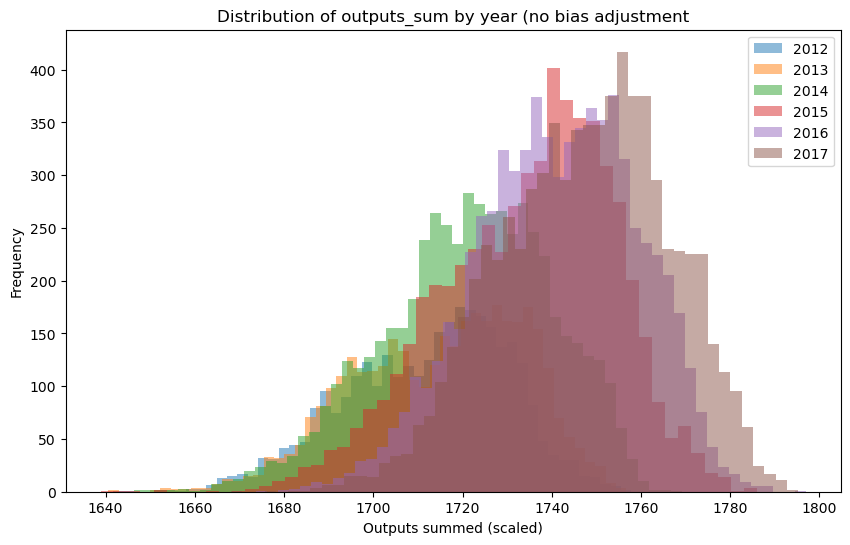

In [5]:
import matplotlib.pyplot as plt

# Group values by year
grouped = outputs_sum.groupby("year")

plt.figure(figsize=(10,6))

# Plot a histogram for each year except 2018
for year, values in grouped:
    if year == 2018:  # skip 2018
        continue
    plt.hist(values.values, bins=50, alpha=0.5, label=str(year))

plt.xlabel("Outputs summed (scaled)")
plt.ylabel("Frequency")
plt.title("Distribution of outputs_sum by year (no bias adjustment")
plt.legend()
plt.show()

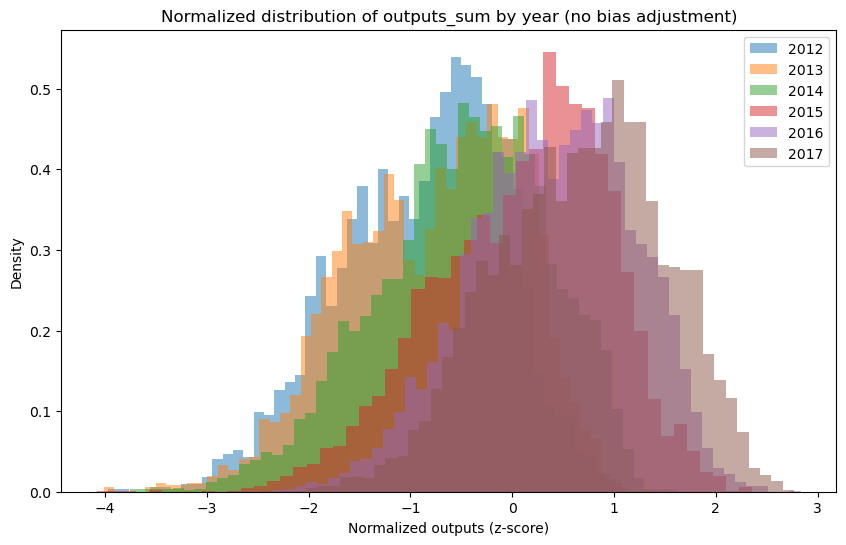

In [6]:
import matplotlib.pyplot as plt

# 1. Remove 2018 datapoints
outputs_no2018 = outputs_sum.where(outputs_sum.year != 2018, drop=True)

# 2. Normalize (z-score: mean 0, std 1)
outputs_norm = (outputs_no2018 - outputs_no2018.mean()) / outputs_no2018.std()

# 3. Group by year
grouped = outputs_norm.groupby("year")

# 4. Plot histograms
plt.figure(figsize=(10,6))
for year, values in grouped:
    plt.hist(values.values, bins=50, alpha=0.5, density=True, label=str(year))

plt.xlabel("Normalized outputs (z-score)")
plt.ylabel("Density")
plt.title("Normalized distribution of outputs_sum by year (no bias adjustment)")
plt.legend()
plt.show()

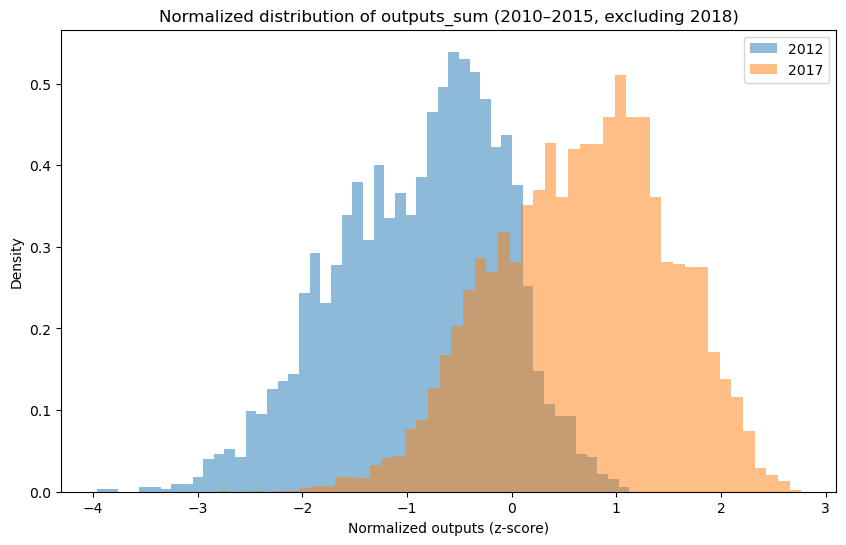

In [15]:
import matplotlib.pyplot as plt

# 1. Remove 2018 datapoints
outputs_no2018 = outputs_sum.where(outputs_sum.year != 2018, drop=True)

# 2. Global normalization (z-score across ALL remaining years)
mean = outputs_no2018.mean()
std = outputs_no2018.std()
outputs_norm = (outputs_no2018 - mean) / std

# 3. Select a subset of years to plot (example: 2010–2015)
years_to_plot = [2012,2017]
subset = outputs_norm.where(outputs_norm.year.isin(years_to_plot), drop=True)

# 4. Group by year
grouped = subset.groupby("year")

# 5. Plot histograms
plt.figure(figsize=(10,6))
for year, values in grouped:
    plt.hist(values.values, bins=50, alpha=0.5, density=True, label=str(year))

plt.xlabel("Normalized outputs (z-score)")
plt.ylabel("Density")
plt.title("Normalized distribution of outputs_sum (2010–2015, excluding 2018)")
plt.legend()
plt.show()

## Taking into account the values (bias adjustment)

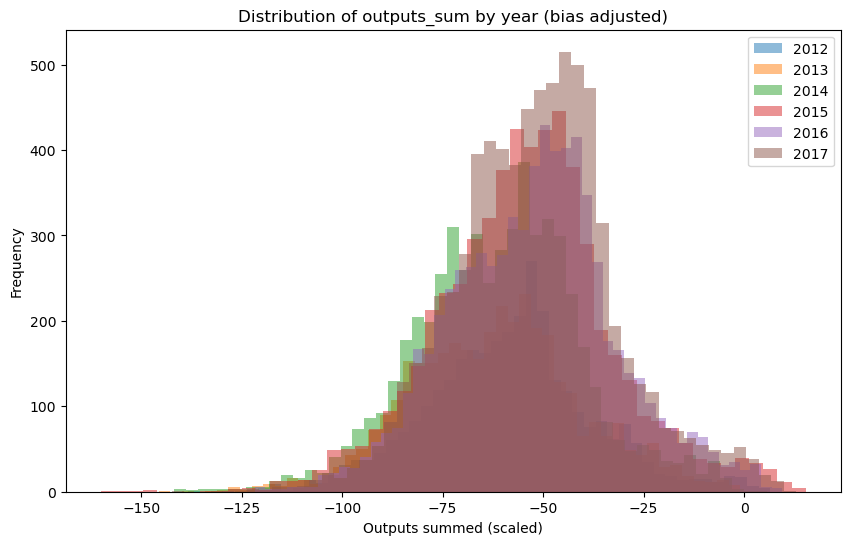

In [7]:
baseline_vals = ds_loaded.baseline[:, 3]  # 1D array of baseline values (time,)
outputs_minus_baseline = outputs_sum - baseline_vals
import matplotlib.pyplot as plt

# Group values by year
grouped = outputs_minus_baseline.groupby("year")

plt.figure(figsize=(10,6))

# Plot a histogram for each year except 2018
for year, values in grouped:
    if year == 2018:  # skip 2018
        continue
    plt.hist(values.values, bins=50, alpha=0.5, label=str(year))

plt.xlabel("Outputs summed (scaled)")
plt.ylabel("Frequency")
plt.title("Distribution of outputs_sum by year (bias adjusted)")
plt.legend()
plt.show()

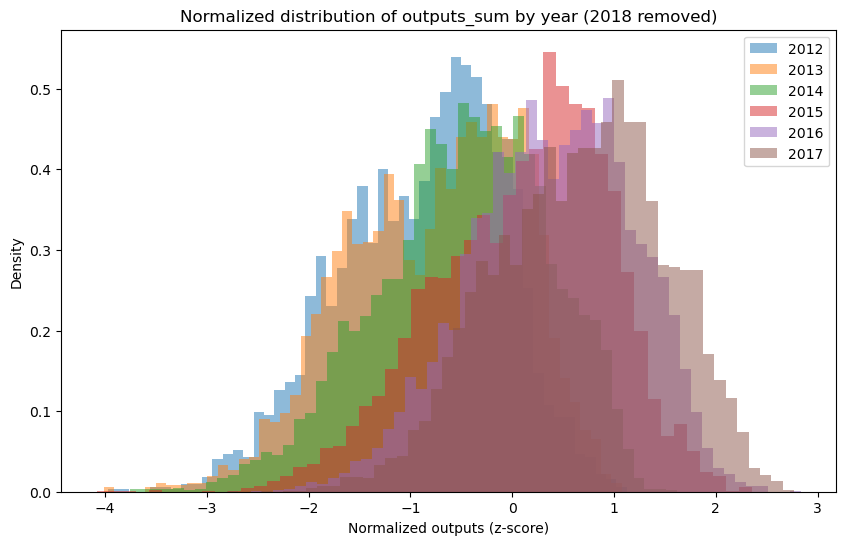

In [ ]:
import matplotlib.pyplot as plt

# 1. Remove 2018 datapoints
baseline_vals = ds_loaded.baseline[:, 3]  # 1D array of baseline values (time,)
outputs_minus_baseline = outputs_sum - baseline_vals
outputs_no2018 = outputs_sum.where(outputs_minus_baseline.year != 2018, drop=True)

# 2. Normalize (z-score: mean 0, std 1)
outputs_norm = (outputs_no2018 - outputs_no2018.mean()) / outputs_no2018.std()

# 3. Group by year
grouped = outputs_norm.groupby("year")

# 4. Plot histograms
plt.figure(figsize=(10,6))
for year, values in grouped:
    plt.hist(values.values, bins=50, alpha=0.5, density=True, label=str(year))

plt.xlabel("Normalized outputs (z-score)")
plt.ylabel("Density")
plt.title("Normalized distribution of outputs_sum by year (bias adjusted)")
plt.legend()
plt.show()

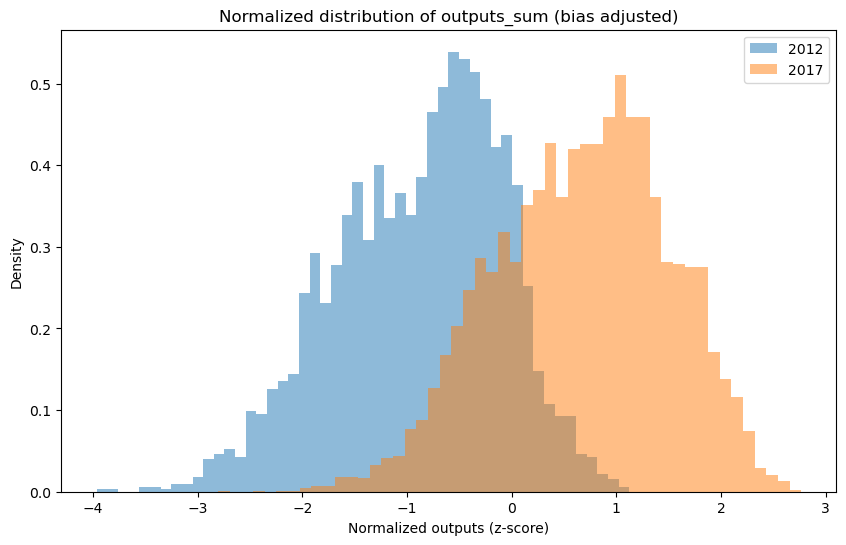

In [8]:
import matplotlib.pyplot as plt

# 1. Remove 2018 datapoints
baseline_vals = ds_loaded.baseline[:, 3]  # 1D array of baseline values (time,)
outputs_minus_baseline = outputs_sum - baseline_vals
outputs_no2018 = outputs_sum.where(outputs_minus_baseline.year != 2018, drop=True)

# 2. Global normalization (z-score across ALL remaining years)
mean = outputs_no2018.mean()
std = outputs_no2018.std()
outputs_norm = (outputs_no2018 - mean) / std

# 3. Select a subset of years to plot (example: 2010–2015)
years_to_plot = [2012,2017]
subset = outputs_norm.where(outputs_norm.year.isin(years_to_plot), drop=True)

# 4. Group by year
grouped = subset.groupby("year")

# 5. Plot histograms
plt.figure(figsize=(10,6))
for year, values in grouped:
    plt.hist(values.values, bins=50, alpha=0.5, density=True, label=str(year))

plt.xlabel("Normalized outputs (z-score)")
plt.ylabel("Density")
plt.title("Normalized distribution of outputs_sum (bias adjusted)")
plt.legend()
plt.show()

### Adding CAMs to the file

In [4]:
outputs_sum = ds_loaded.outputs.sum(dim="direction")  # (time,)

In [5]:
ds_loaded

<xarray.Dataset>
Dimensions:    (time: 37780, direction: 4)
Coordinates:
  * time       (time) datetime64[ns] 2012-01-01T14:57:56 ... 2018-12-31T17:00:37
    year       (time) int64 ...
    month      (time) int64 ...
  * direction  (direction) object 'north' 'south' 'east' 'west'
Data variables:
    outputs    (time, direction) float64 5.402e-09 1.298e-09 ... 1.293e-06
    baseline   (time, direction) float64 ...
Attributes:
    description:  Satellite outputs & baselines with times

In [6]:
ds_loaded.month.values

array([ 1,  1,  1, ..., 12, 12, 12])

In [7]:
def make_monthly_ds(year, month, cams):
    # Replace with your actual arrays for this month
    north = cams.vmr_n.values
    south = cams.vmr_s.values
    east  = cams.vmr_e.values
    west  = cams.vmr_w.values

    return xr.Dataset(
        {
            "north": (("height", "coord_north"), north),
            "south": (("height", "coord_south"), south),
            "east":  (("height", "coord_east"),  east),
            "west":  (("height", "coord_west"),  west),
        },
        coords={
            "height": np.arange(north.shape[0]),
            "coord_north": np.arange(north.shape[1]),
            "coord_south": np.arange(south.shape[1]),
            "coord_east": np.arange(east.shape[1]),
            "coord_west": np.arange(west.shape[1]),
            "year": year,
            "month": month,
        }
    )

In [8]:
import numpy as np
import xarray as xr
import pandas as pd

# Existing dataset (your ds_loaded)
# ds_loaded = ...

# --- Build the extra dataset ---
data_list = []
years =['2012','2013','2014','2015','2016','2017']
months = ['01','02','03','04','05','06','07','08','09','10','11','12']
for year in years:
    for month in months:
        # Cams field for a particular month
        cams = xr.open_dataset(f"/group/chemistry/acrg/LPDM/bc/SOUTHAMERICA/ch4_SOUTHAMERICA_{year}{month}_CAMS-inversion.nc")
        year,month = int(year), int(month)
        print(year,month)
        monthly_ds = make_monthly_ds(year,month, cams)

        data_list.append(monthly_ds)


ds_extra = xr.concat(data_list, dim="time_index")

# Attach year/month as coordinates along that new dimension
ds_extra = ds_extra.assign_coords(
    year=("time_index", [ds.year.item() for ds in data_list]),
    month=("time_index", [ds.month.item() for ds in data_list]),
)

#ds_merged = xr.merge([ds_loaded, ds_extra], compat='override')




2012 1
2012 2
2012 3
2012 4
2012 5
2012 6
2012 7
2012 8
2012 9
2012 10
2012 11
2012 12
2013 1
2013 2
2013 3
2013 4
2013 5
2013 6
2013 7
2013 8
2013 9
2013 10
2013 11
2013 12
2014 1
2014 2
2014 3
2014 4
2014 5
2014 6
2014 7
2014 8
2014 9
2014 10
2014 11
2014 12
2015 1
2015 2
2015 3
2015 4
2015 5
2015 6
2015 7
2015 8
2015 9
2015 10
2015 11
2015 12
2016 1
2016 2
2016 3
2016 4
2016 5
2016 6
2016 7
2016 8
2016 9
2016 10
2016 11
2016 12
2017 1
2017 2
2017 3
2017 4
2017 5
2017 6
2017 7
2017 8
2017 9
2017 10
2017 11
2017 12


In [9]:
year_vals = ds_extra.year.values.astype(int)
month_vals = ds_extra.month.values.astype(int)
time_index = pd.to_datetime([f"{y}-{m:02d}-01" for y, m in zip(year_vals, month_vals)])
south_h1 = ds_extra.south.sel(height=1)

south_h1 = south_h1.rename({"time_index": "time"})
south_h1 = south_h1.assign_coords(time=time_index)

south_mean = south_h1.mean(dim="coord_south")
south_monthly = south_mean.resample(time="1M").mean()


In [10]:
outputs_no2018 = outputs_sum.sel(time=outputs_sum.time.dt.year != 2018)*1e9
outputs_monthly = outputs_no2018.resample(time="1M").mean()
# Convert outputs_monthly to pandas Series for easy alignment
outputs_series = pd.Series(outputs_monthly.values, index=outputs_monthly.time.values)

# Subtract south_monthly from outputs
diff_monthly = outputs_series - (south_monthly.values*1e9)
diff_series = pd.Series(diff_monthly, index=south_monthly.time.values)



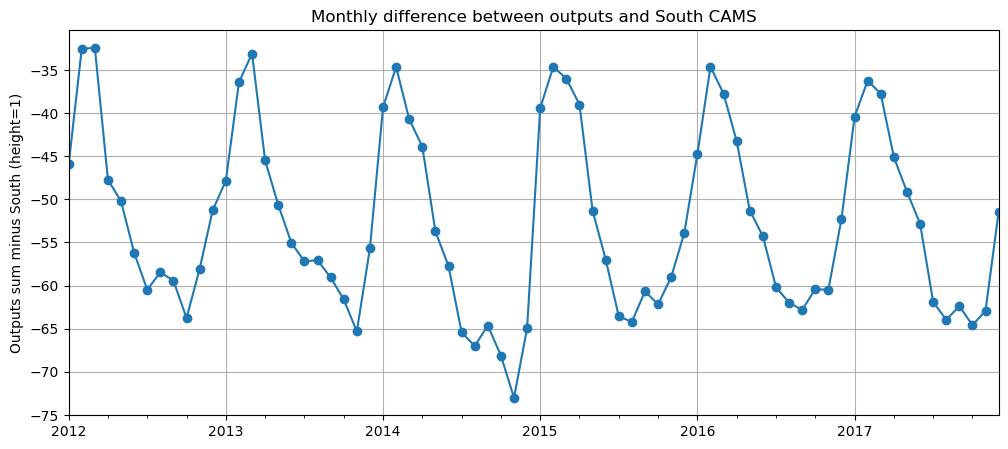

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
diff_series.plot(marker="o")
plt.ylabel("Outputs sum minus South (height=1)")
plt.title("Monthly difference between outputs and South CAMS")
plt.grid(True)
plt.show()

### CAMS histograms

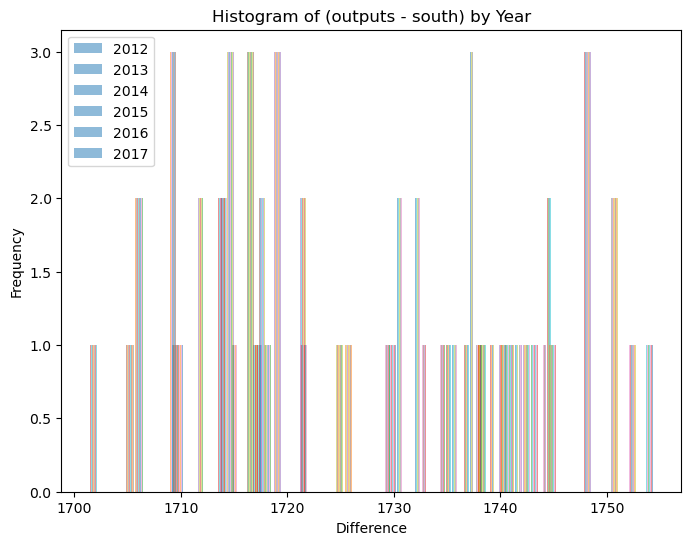

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Make a datetime index for south_h1
year_vals = ds_extra.year.values
month_vals = ds_extra.month.values
time_index = pd.to_datetime([f"{y}-{m:02d}-01" for y, m in zip(year_vals, month_vals)])

south_h1 = ds_extra.south.sel(height=1)
south_h1 = south_h1.assign_coords(time=("time_index", time_index))

# Now south_h1 has a proper time coordinate
south_h1 = south_h1.swap_dims({"time_index": "time"}).drop_vars(["year","month"])

# 2. Compute monthly means for south
south_monthly = south_h1.resample(time="1M").mean()

# 3. Compute monthly means for outputs (excluding 2018, already done)
outputs_monthly = outputs_no2018.resample(time="1M").mean()

# 4. Align both time series and subtract
diff = outputs_monthly - south_monthly

# Group by year
grouped = diff.groupby("time.year")

plt.figure(figsize=(8,6))

# Plot each year as a separate histogram
for year, data in grouped:
    plt.hist(
        data.values,
        bins=20,
        alpha=0.5,
        label=str(year)
    )

plt.title("Histogram of (outputs - south) by Year")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.legend()
plt.show()

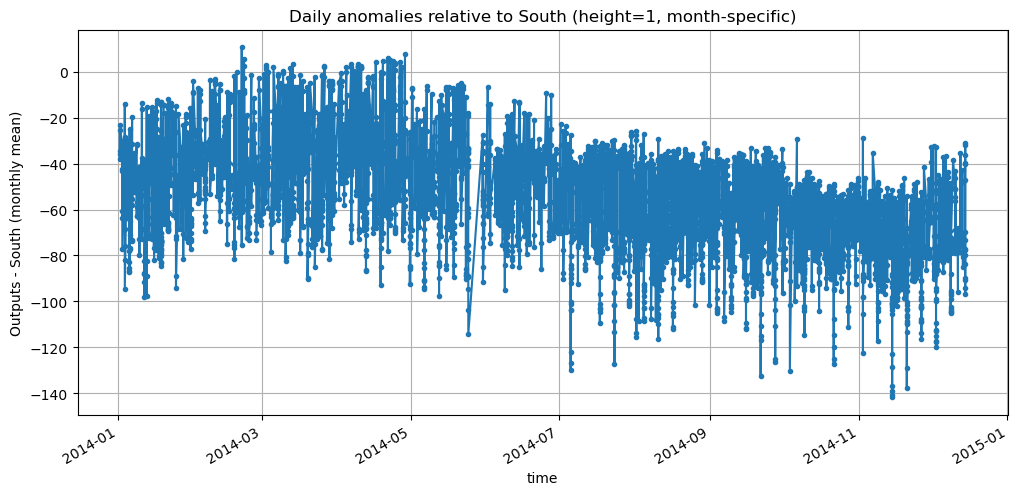

In [13]:
# --- 1. Compute monthly mean of south_h1 ---
south_h1 = ds_extra.south.sel(height=1).mean(dim="coord_south")

# Build datetime index from year/month in ds_extra
year_vals = ds_extra.year.values
month_vals = ds_extra.month.values
south_time = pd.to_datetime([f"{y}-{m:02d}-01" for y, m in zip(year_vals, month_vals)])

# Assign datetime coords
south_h1 = xr.DataArray(
    south_h1.values,
    dims=["time"],
    coords={"time": south_time},
    name="south_h1"
)

# 1. Compute monthly mean of south_h1 (year+month specific!)
south_h1_monthly = south_h1.resample(time="1M").mean()

# 2. Broadcast south_h1_monthly back to daily resolution by reindexing
# This will match each daily timestamp to its monthly mean
south_h1_baseline = south_h1_monthly.reindex(time=outputs_no2018.time, method="ffill")

# 3. Subtract (daily outputs - monthly south baseline)
diff_daily = outputs_no2018 - (south_h1_baseline*1e9)

# 4. Plot example year
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
diff_daily.sel(time="2014").plot(marker=".")
plt.ylabel("Outputs - South (monthly mean)")
plt.title("Daily anomalies relative to South (height=1, month-specific)")
plt.grid(True)
plt.show()


In [26]:
outputs_no2018

<xarray.DataArray 'outputs' (time: 32422)>
array([1723.8734758 , 1724.99932215, 1725.09695927, ..., 1788.58998187,
       1752.55474057, 1729.47738733])
Coordinates:
  * time     (time) datetime64[ns] 2012-01-01T14:57:56 ... 2017-12-31T17:28:2...
    year     (time) int64 2012 2012 2012 2012 2012 ... 2017 2017 2017 2017 2017
    month    (time) int64 ...

In [28]:
diff_daily

<xarray.DataArray (time: 32422)>
array([         nan,          nan,          nan, ..., -15.49296668,
       -51.52820798, -74.60556121])
Coordinates:
  * time     (time) datetime64[ns] 2012-01-01T14:57:56 ... 2017-12-31T17:28:2...
    year     (time) int64 2012 2012 2012 2012 2012 ... 2017 2017 2017 2017 2017
    month    (time) int64 ...

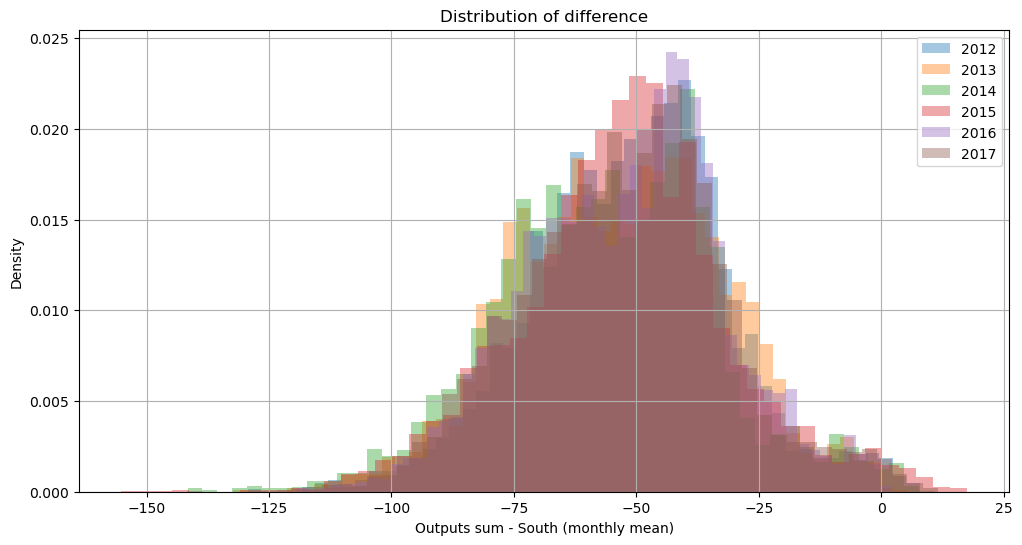

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract years except 2018 (already removed from outputs_no2018)
years = np.unique(diff_daily.time.dt.year.values)

# 2. Plot histograms per year
plt.figure(figsize=(12,6))

for y in years:
    vals = diff_daily.sel(time=str(y)).values
    plt.hist(
        vals, bins=50, alpha=0.4, label=str(y), density=True
    )

plt.xlabel("Outputs sum - South (monthly mean)")
plt.ylabel("Density")
plt.title("Distribution of difference")
plt.legend()
plt.grid(True)
plt.show()

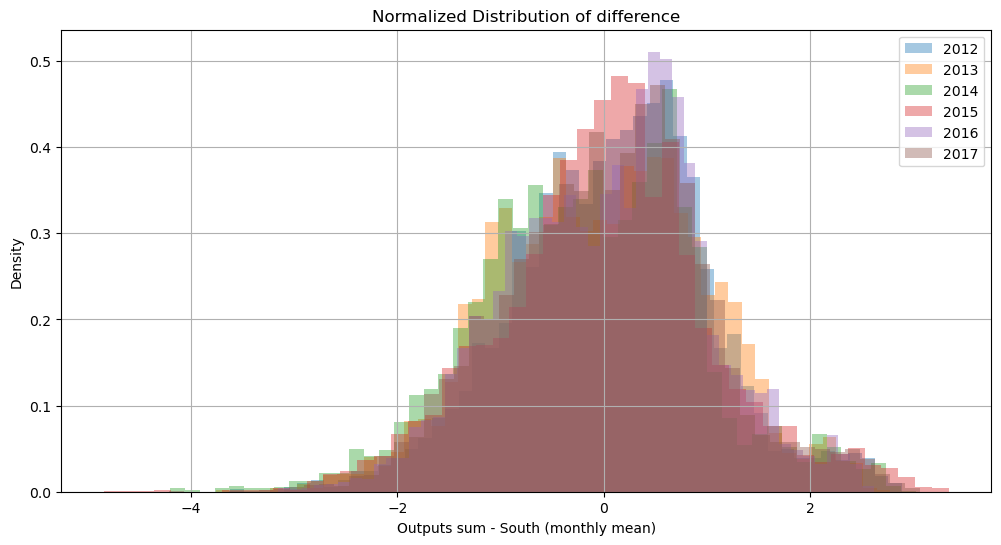

In [18]:
import matplotlib.pyplot as plt
import numpy as np

normalized_diff_daily = (diff_daily - np.mean(diff_daily))/np.std(diff_daily)
# 1. Extract years except 2018 (already removed from outputs_no2018)
years = np.unique(diff_daily.time.dt.year.values)

# 2. Plot histograms per year
plt.figure(figsize=(12,6))

for y in years:
    vals = normalized_diff_daily.sel(time=str(y)).values
    plt.hist(
        vals, bins=50, alpha=0.4, label=str(y), density=True
    )

plt.xlabel("Outputs sum - South (monthly mean)")
plt.ylabel("Density")
plt.title("Normalized Distribution of difference")
plt.legend()
plt.grid(True)
plt.show()

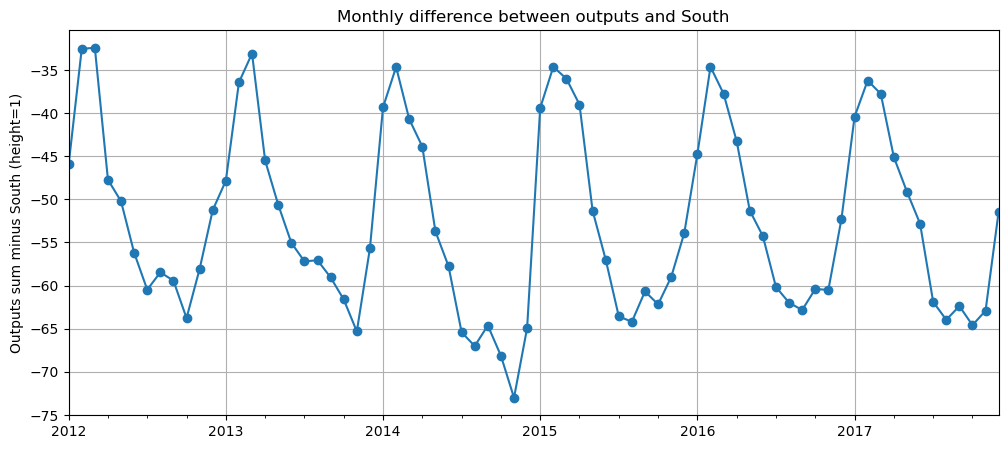

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
diff_series.plot(marker="o")
plt.ylabel("Outputs sum minus South (height=1)")
plt.title("Monthly difference between outputs and South")
plt.grid(True)
plt.show()